# RQ3: How do different regression models compare in predicting song popularity, and which model performs best?

Dataset: Almost Million Songs Dataset (Kaggle)  
Target: Popularity  
Task: Regression Model Comparison

In [1]:
# ── Import libraries ─────────────────────────

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries loaded ")

Libraries loaded 


In [2]:
# ── Load dataset ─────────────────────────

data_path = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            data_path = os.path.join(dirname, filename)
            print(f"Dataset found: {data_path}")
            break

df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Dataset found: /kaggle/input/datasets/anantsinghal786/almost-million-songs-dataset-2025-16-features/tracks.csv
Shape: (899702, 16)


,track_id,genres,track_artists,tempo,energy,key,popularity,mode,time_signature,speechiness,danceability,valence,acousticness,liveness,instrumentalness,name
0,07vS8obfeZbr8H4MgQfXR7,"['indie pop', 'la indie', 'pov: indie']",Phoebe Bridgers,97.129,0.123,7.0,0.0,1.0,4.0,0.0407,0.373,0.138,0.9480,0.0816,0.000000,Friday I'm In Love - Recorded at Spotify Studi...
1,1PEqh7awkpuepLBSq8ZwqD,"['lilith', 'new wave pop']",NaN,103.773,0.453,5.0,71.0,1.0,4.0,0.0348,0.744,0.122,0.6270,0.0898,0.421000,I Love You Always Forever
2,7E8pPgBY84oDaXRcqODavR,"['deep groove house', 'house', 'tech house']",NaN,122.030,0.878,9.0,0.0,0.0,4.0,0.0357,0.747,0.897,0.0794,0.3700,0.000531,Love Too Deep - Radio Edit
3,0Atml4huw4Fgyk6YSHiK4M,[],NaN,84.099,0.484,7.0,0.0,1.0,4.0,0.0356,0.604,0.564,0.1000,0.0865,0.000000,No Tiren Las Botellas
4,4WYDmIZrwxBHdBYdvi5oQO,"['chill lounge', 'deep chill']",NaN,156.017,0.447,0.0,7.0,1.0,4.0,0.0613,0.761,0.761,0.0616,0.0822,0.873000,El Momento de Despertar - Blue Sky Mix


In [3]:
# ── Preprocessing ─────────────────────────

TARGET = 'popularity'

drop_cols = [c for c in ['track_id','song_id','title','artist_name','name','id','genres','track_artists'] if c in df.columns]
df = df.drop(columns=drop_cols)

df = df.select_dtypes(include=[np.number])

df = df.dropna(subset=[TARGET])
df = df.fillna(df.median())

if len(df) > 120_000:
    df = df.sample(120_000, random_state=42).reset_index(drop=True)

FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (96000, 11) Test: (24000, 11)


In [4]:
# ── Scaling ─────────────────────────

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

In [5]:
# ── Model Training ─────────────────────────

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10),
    "Random Forest": RandomForestRegressor(n_estimators=80, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(),
   
}

results = []

for name, model in models.items():
    
    if name in ["Linear Regression", "Ridge Regression", "Lasso Regression", "SVR"]:
        model.fit(X_tr_sc, y_train)
        pred = model.predict(X_te_sc)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    results.append([name, mae, rmse, r2])
    
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}")

Linear Regression: MAE=16.83, RMSE=19.56, R2=0.0393
Ridge Regression: MAE=16.83, RMSE=19.56, R2=0.0393
Lasso Regression: MAE=16.95, RMSE=19.63, R2=0.0323
Decision Tree: MAE=16.59, RMSE=19.64, R2=0.0311
Random Forest: MAE=16.37, RMSE=19.17, R2=0.0764
Gradient Boosting: MAE=16.43, RMSE=19.20, R2=0.0739


In [6]:
# ── Table 3.1: Model Comparison ─────────────────

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df = results_df.sort_values(by="MAE")

styled_table = results_df.style\
    .format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R2": "{:.3f}"})\
    .set_caption("Table 3.1: Model Performance Comparison (RQ3)")\
    .background_gradient(cmap="Blues", subset=["MAE", "RMSE"])\
    .background_gradient(cmap="Greens", subset=["R2"])\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt'
    })

display(styled_table)

,Model,MAE,RMSE,R2
4,Random Forest,16.37,19.17,0.076
5,Gradient Boosting,16.43,19.20,0.074
3,Decision Tree,16.59,19.64,0.031
0,Linear Regression,16.83,19.56,0.039
1,Ridge Regression,16.83,19.56,0.039
2,Lasso Regression,16.95,19.63,0.032


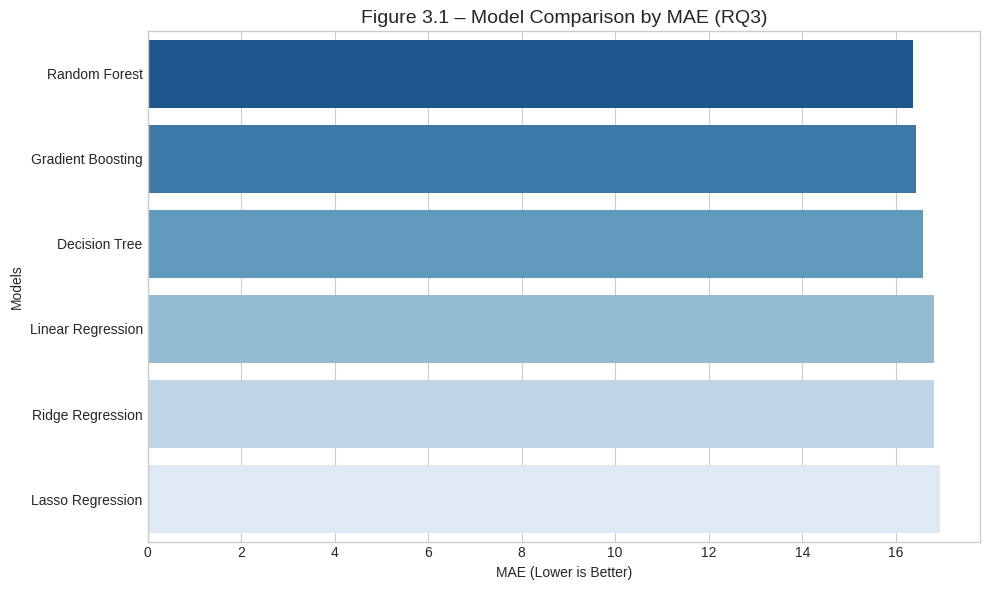

In [7]:
# ── Figure 3.1: Model Comparison ─────────────────

plt.figure(figsize=(10, 6))

sns.barplot(data=results_df, x="MAE", y="Model", palette="Blues_r")

plt.title("Figure 3.1 – Model Comparison by MAE (RQ3)", fontsize=14)
plt.xlabel("MAE (Lower is Better)")
plt.ylabel("Models")

plt.tight_layout()
plt.show()

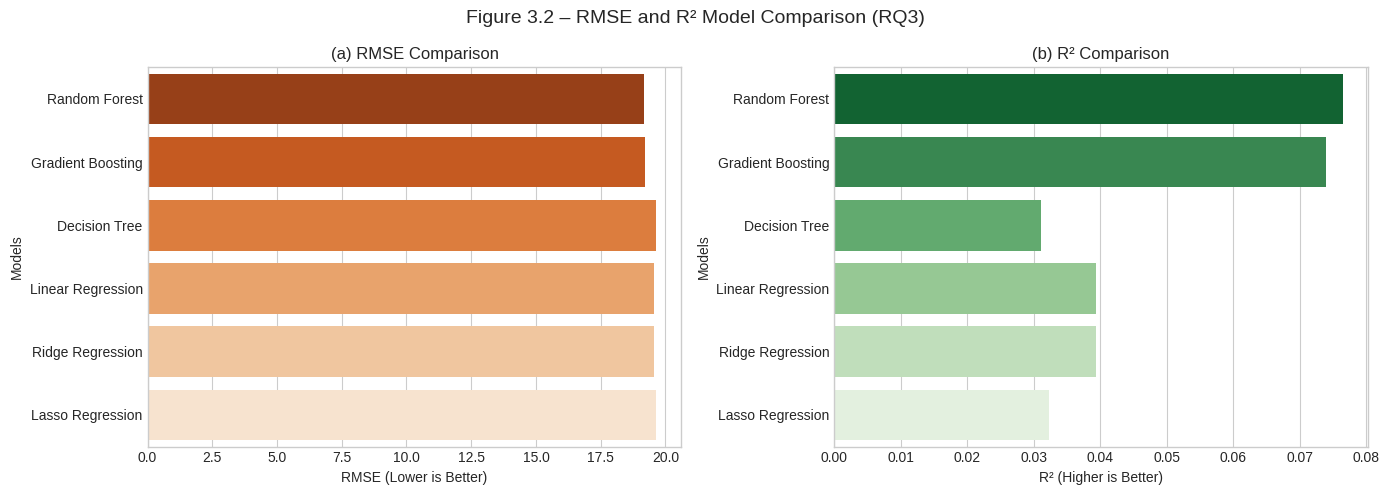

In [8]:
# ── Figure 3.2: RMSE and R² Comparison ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
sns.barplot(data=results_df, x="RMSE", y="Model", ax=axes[0], palette="Oranges_r")
axes[0].set_title("(a) RMSE Comparison")
axes[0].set_xlabel("RMSE (Lower is Better)")
axes[0].set_ylabel("Models")

# R²
sns.barplot(data=results_df, x="R2", y="Model", ax=axes[1], palette="Greens_r")
axes[1].set_title("(b) R² Comparison")
axes[1].set_xlabel("R² (Higher is Better)")
axes[1].set_ylabel("Models")

plt.suptitle("Figure 3.2 – RMSE and R² Model Comparison (RQ3)", fontsize=14)

plt.tight_layout()
plt.show()